In [1]:
!pip install -q MicrogliaResearchModel==1.0.1 mesa==3.5.1 matplotlib==3.10.8


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from MicrogliaResearchModel.model import run_sim

from __future__ import annotations
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

c:\Users\wolfe\OneDrive\Desktop\Microglia-Poster-MAA-Golden-Section-2026-\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
apoe_genotypes = ["3/3", "3/4", "4/4"]

all_runs = []
base_seed = 32
n_repeats = 10

for apoe in apoe_genotypes:
  for i in range(n_repeats):
      #params = base_params.copy()
      #params["seed"] = base_seed + i

      # Unpack the model and df from the run_sim output
      model_output, df_output = run_sim(

                steps=500,
                seed=base_seed + i,
                # microglia
                m0=10,
                m1=2,
                m2=3,

                # neuron network
                h_neurons=15,
                d_neurons=5,

                # behavior
                eat=0.7,
                base_eat=0.7,
                sense=0.7,
                base_sense=0.7,
                damage=0.005,

                # spatial
                ndist=5,
                radius=3,

                # astrocytes
                a0_astro=15,
                a1_astro=2,
                a2_astro=3,
                astro_radius=2,
                a2_res=15,

                # recruitment
                recruit_thresh=4.0,
                recruit_prob=0.1,

                # lipid metabolism
                neuron_ld_production_rate=0.2,
                neuron_ld_packet_size=0.1,
                neuron_to_astro_ld_transfer_prob=0.5,
                astro_ld_oxidation_rate=0.3,
                microglia_ld_pro_inflam_threshold=5.0,

                # amyloid
                initial_amyloid_patches=2,
                amyloid_decay=0.06,
                amyloid_growth=0.08,
                amyloid_diffusion=0.02,
                amyloid_fibril_thresh=2.0,

                # microglia-amyloid interaction
                microglia_ld_from_amyloid=0.5,
                microglia_amyloid_clearance=0.1,
                microglia_amyloid_impairment_factor=0.5,

                # genetics
                apoe_genotype=apoe,
                trem2_mutation_rate=0,
                trem2_mutant_activity=0.5,
              )

      if not isinstance(df_output, pd.DataFrame):
          raise TypeError("Expected run_sim() to return a pandas DataFrame as its second element.")

      run_df = df_output.copy()
      run_df["replicate"] = i + 1
      run_df["seed"] = base_seed + i
      run_df["apoe_genotype"] = apoe #params["apoe_genotype"]
      all_runs.append(run_df)

df = pd.concat(all_runs, ignore_index=True)
df.to_csv("data/run_sim_replicates_10_timeseries.csv", index=False)

print(df.head())
print("Saved to data/run_sim_replicates_10_timeseries.csv")

In [3]:
df = pd.read_csv("data/run_sim_replicates_10_timeseries.csv")
# Need to split dataset into three apoe cases
df1 = df[df["apoe_genotype"] == "3/3"]
df2 = df[df["apoe_genotype"] == "3/4"]
df3 = df[df["apoe_genotype"] == "4/4"]

In [11]:
def plot_time_vs_inflammation_colorLD_avg(
    df,
    outpath="time_vs_inflammation_colorLD_avg.png",
    ci=0.95
):
    apoe = df["apoe_genotype"].iloc[0]
    required = [
        "replicate",
        "step",
        "total_pro_inflammation",
        "total_ld_microglia",
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"DataFrame missing required columns: {missing}")

    grouped = (
        df.groupby("step")
        .agg(
            mean_inflam=("total_pro_inflammation", "mean"),
            std_inflam=("total_pro_inflammation", "std"),
            n=("total_pro_inflammation", "count"),
            mean_ld=("total_ld_microglia", "mean"),
        )
        .reset_index()
        .sort_values("step")
    )

    # Fix x-axis spacing (divide by 2)
    grouped["step_fixed"] = grouped["step"] / 2

    z = 1.96 if np.isclose(ci, 0.95) else 1.96
    grouped["se_inflam"] = grouped["std_inflam"] / np.sqrt(grouped["n"].clip(lower=1))
    grouped["inflam_lo"] = grouped["mean_inflam"] - z * grouped["se_inflam"]
    grouped["inflam_hi"] = grouped["mean_inflam"] + z * grouped["se_inflam"]

    plt.figure(figsize=(8, 5))

    # CI bars (background)
    plt.vlines(
        grouped["step_fixed"],
        grouped["inflam_lo"],
        grouped["inflam_hi"],
        alpha=0.4,
        linewidth=1,
        zorder=1
    )

    # Mean line
    plt.plot(
        grouped["step_fixed"],
        grouped["mean_inflam"],
        linewidth=1.5,
        alpha=0.8,
        zorder=2
    )

    # Scatter with FIXED color scale
    scatter = plt.scatter(
        grouped["step_fixed"],
        grouped["mean_inflam"],
        c=grouped["mean_ld"],
        cmap="plasma",
        s=40,
        vmin=0,
        vmax=5000,
        zorder=3
    )

    # FIXED y-axis
    plt.ylim(0, 5000)

    plt.xlabel("Time (step)")
    plt.ylabel("Mean total pro-inflammation")
    plt.title(f"Average Pro-Inflammation Over Time\nColored by Mean Microglial Lipid Droplets for APOE {apoe}")

    cbar = plt.colorbar(scatter)
    cbar.set_label("Mean total lipid droplets in microglia")

    plt.tight_layout()
    plt.savefig(outpath)
    plt.show()

    print(f"Saved {outpath}")

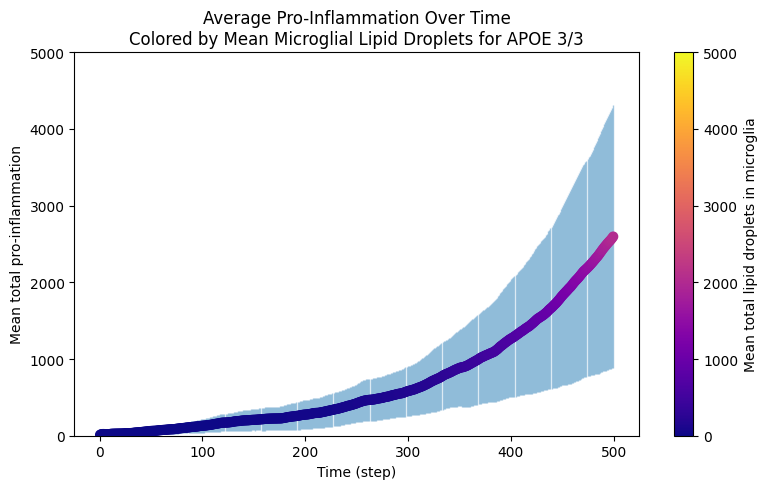

Saved time_vs_inflammation_colorLD_avg.png


In [12]:
plot_time_vs_inflammation_colorLD_avg(df1)

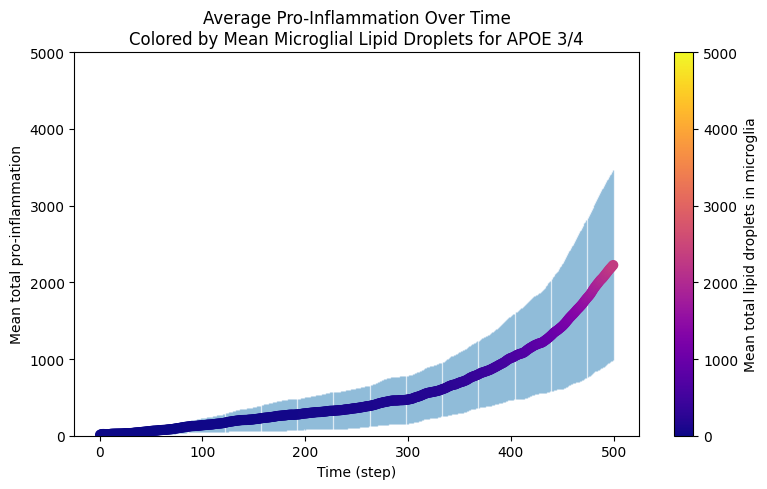

Saved time_vs_inflammation_colorLD_avg.png


In [13]:
plot_time_vs_inflammation_colorLD_avg(df2)

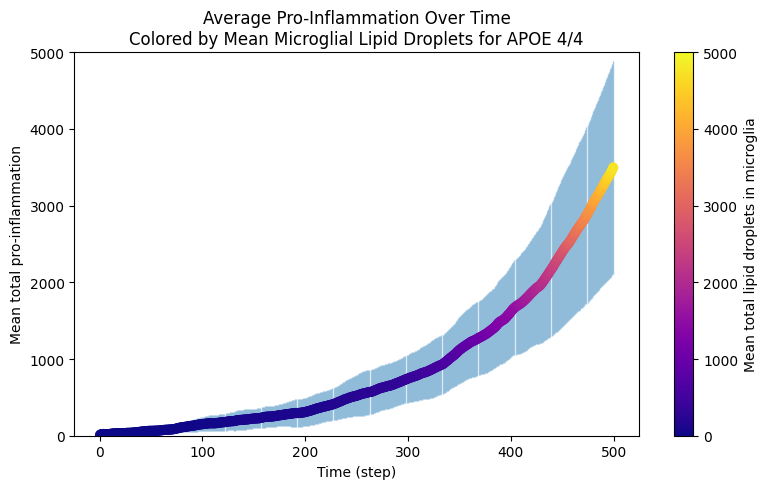

Saved time_vs_inflammation_colorLD_avg.png


In [14]:
plot_time_vs_inflammation_colorLD_avg(df3)

In [8]:
def plot_percent_neuron_loss_and_ldam_dam_avg(
    df,
    outpath="percent_neuron_loss_avg.png",
    ci=0.95,
    show=True
):
    apoe = df["apoe_genotype"].iloc[0]
    required = ["replicate", "step", "neurons_total", "LDAM_fraction", "DAM_fraction"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"DataFrame missing required columns: {missing}")

    df = df.copy()

    # Compute percent neuron loss per replicate
    df["pct_neuron_loss"] = np.nan

    for rep in df["replicate"].unique():
        rep_mask = df["replicate"] == rep
        rep_df = df.loc[rep_mask]

        initial_step = rep_df["step"].min()
        N0 = rep_df.loc[rep_df["step"] == initial_step, "neurons_total"].iloc[0]

        if N0 == 0:
            raise ValueError(f"Initial neuron count is zero for replicate {rep}")

        df.loc[rep_mask, "pct_neuron_loss"] = (
            100.0 * (1.0 - rep_df["neurons_total"] / N0)
        )

    # Convert fractions to percent
    df["LDAM_fraction"] = 100.0 * df["LDAM_fraction"]
    df["DAM_fraction"] = 100.0 * df["DAM_fraction"]

    # Aggregate across replicates
    grouped = (
        df.groupby("step")
        .agg(
            mean_loss=("pct_neuron_loss", "mean"),
            std_loss=("pct_neuron_loss", "std"),
            n_loss=("pct_neuron_loss", "count"),

            mean_ldam=("LDAM_fraction", "mean"),
            std_ldam=("LDAM_fraction", "std"),
            n_ldam=("LDAM_fraction", "count"),

            mean_dam=("DAM_fraction", "mean"),
            std_dam=("DAM_fraction", "std"),
            n_dam=("DAM_fraction", "count"),
        )
        .reset_index()
        .sort_values("step")
    )

    z = 1.96 if np.isclose(ci, 0.95) else 1.96

    # Compute CIs
    for prefix in ["loss", "ldam", "dam"]:
        grouped[f"se_{prefix}"] = grouped[f"std_{prefix}"] / np.sqrt(grouped[f"n_{prefix}"].clip(lower=1))
        grouped[f"{prefix}_lo"] = grouped[f"mean_{prefix}"] - z * grouped[f"se_{prefix}"]
        grouped[f"{prefix}_hi"] = grouped[f"mean_{prefix}"] + z * grouped[f"se_{prefix}"]

    # Plot
    plt.figure(figsize=(6, 5))

    # LDAM
    plt.plot(grouped["step"], grouped["mean_ldam"], label="LDAM Fraction", linewidth=2)
    #plt.fill_between(grouped["step"], grouped["ldam_lo"], grouped["ldam_hi"], alpha=0.2)

    # DAM
    plt.plot(grouped["step"], grouped["mean_dam"], label="DAM Fraction", linewidth=2)
    #plt.fill_between(grouped["step"], grouped["dam_lo"], grouped["dam_hi"], alpha=0.2)

    # Neuron loss
    plt.plot(grouped["step"], grouped["mean_loss"], label="Neuron Loss", linewidth=2)
    #plt.fill_between(grouped["step"], grouped["loss_lo"], grouped["loss_hi"], alpha=0.2)

    plt.xlabel("Step")
    plt.ylabel("Percent (%)")
    plt.title(f"Neuron Loss and Microglial States for APOE {apoe}")
    plt.ylim(0, 100)
    plt.legend()

    plt.tight_layout()
    plt.savefig(outpath)
    print(f"Saved {outpath}")

    if show:
        plt.show()
    else:
        plt.close()

Saved percent_neuron_loss_avg.png


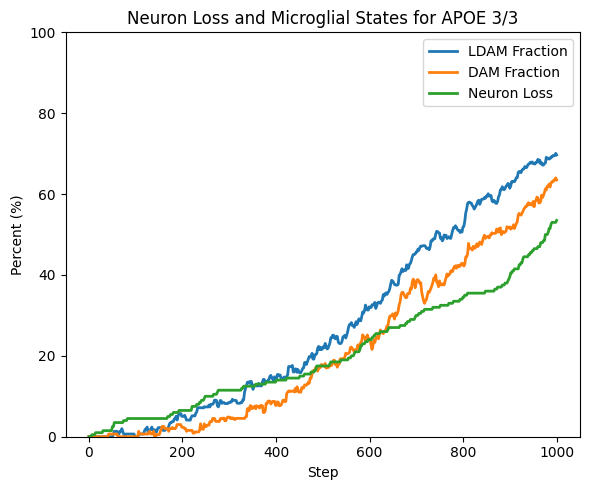

In [15]:
plot_percent_neuron_loss_and_ldam_dam_avg(df1)

Saved percent_neuron_loss_avg.png


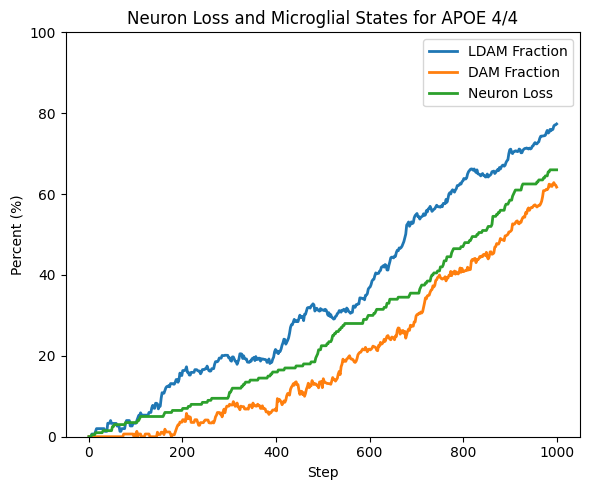

In [16]:
plot_percent_neuron_loss_and_ldam_dam_avg(df3)